## Task 1: Data Loading and Exploration

In [5]:
import pandas as pd
df = pd.read_csv("Reviews.csv")
df = df.head(5000)
df.to_csv("Reviews.csv", index=False)

In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'analysis.ipynb', 'charts', 'Reviews.csv.csv', 'summary.pdf']


In [6]:
df.shape

(5000, 10)

In [7]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

The dataset contains product reviews from Amazon.
The 'Text' column contains the review content.
The 'Score' column represents the rating given by the user.

## Task 2: Data Cleaning

In [8]:
df = df.dropna(subset=['Text'])

In [9]:
print("Before:", df.shape)

df = df.dropna(subset=['Text'])

print("After:", df.shape)

Before: (5000, 10)
After: (5000, 10)


In [10]:
df['Text'].isnull().sum()

np.int64(0)

No missing values were found in the 'Text' column.

In [11]:
df = df.drop_duplicates(subset = ['Text'])
df.shape

(4984, 10)

In [12]:
df = df[['Text','Score']]
df.shape

(4984, 2)

Duplicate reviews were removed from the dataset.
After cleaning, only 'Text' and 'Score' columns were kept for further analysis.

## Task 3: Sentiment Analysis

In [ ]:
pip install textblob

In [13]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity>0:
        return "Positive"
    elif polarity<0:
        return "Negative"
    else:
        return "Neutral"
df['sentiment'] = df['Text'].apply(get_sentiment)

df.head()

,Text,Score,sentiment
0,I have bought several of the Vitality canned d...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative
2,This is a confection that has been around a fe...,4,Positive
3,If you are looking for the secret ingredient i...,2,Positive
4,Great taffy at a great price. There was a wid...,5,Positive


In [15]:
df['Sentiment'] = df['Text'].apply(get_sentiment)
df['Sentiment'].value_counts()

Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64

In this step, sentiment analysis was performed using the TextBlob library.
Each review's polarity score was calculated and used to classify the sentiment.

Reviews were categorized as Positive, Negative, or Neutral based on the polarity value.
A new column 'Sentiment' was added to the dataset to store these labels.

## Task 4: Data Visualization

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

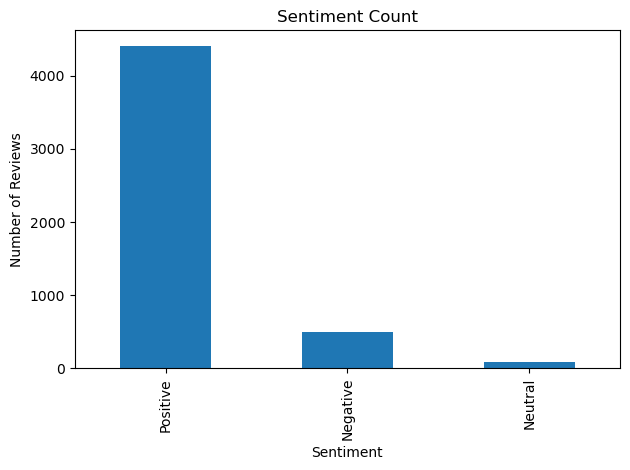

In [17]:
df['Sentiment'].value_counts().plot(kind ='bar')

plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.savefig("charts/01_chart.png")
plt.show()

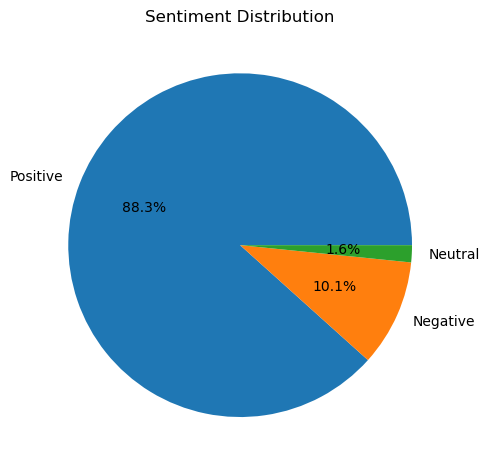

In [19]:
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Sentiment Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig("charts/02_chart.png")
plt.show()

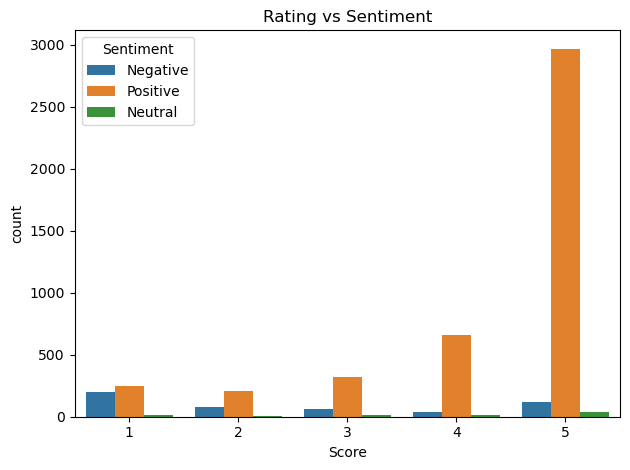

In [18]:
sns.countplot(x='Score', hue='Sentiment', data=df)

plt.title("Rating vs Sentiment")

plt.tight_layout()
plt.savefig("charts/03_chart.png")
plt.show()

In this step, visualizations were created to analyze sentiment distribution.
The bar chart shows the count of each sentiment category.
The pie chart represents the percentage distribution.
The third chart compares product ratings with sentiment.

## Task 5: Insights and Summary

In [20]:
(df['Sentiment'].value_counts(normalize=True) * 100).round(2)

Sentiment
Positive    88.34
Negative    10.05
Neutral      1.61
Name: proportion, dtype: float64

Around 88.34% of the reviews are positive, indicating that most customers are satisfied with the products.

Customers mostly complain about issues such as bad taste, poor packaging, and delivery problems in negative reviews.

One surprising observation is that some reviews with low ratings still have positive sentiment in the text, showing inconsistency between ratings and written feedback.

Overall, the data suggests that while customer satisfaction is generally high, there are specific areas that need improvement.

Recommendation: The business should focus on improving packaging quality and maintaining consistent product standards to reduce negative feedback.